# Overall experiment results

This notebook collects the test-set results from the query-based experiments and turns them into publication-ready tables and figures.

The main metric is nDCG, reported at different cutoffs `k`. The parameter `qxm` is the number of similar queries assigned to each query-specific model; lower values mean more local models, while higher values share one model across larger query groups.


## Setup

The first cells import the plotting stack and define a consistent color palette for the models. The palette keeps the RuleTreeRank variants, KNN baselines, and boosted-tree baselines visually stable across all figures.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_theme(style="whitegrid")

In [ ]:
palette = {
    "RuleTreeRank":        "#D55E00",  # orange-red
    "Mix-RuleTreeRank":    "#E69F00",  # orange (lighter)
    "KNN Regressor":       "#009E73",  # green
    "KNNwPDT":             "#56B4E9",  # light blue-green
    "LambdaMART":          "#000000",  # black (reference strong baseline)
    "ILMART":              "#7F7F7F",  # gray (variant)
    "RandomRanker":        "#BDBDBD",
    "ListNET":             "#6A3D9A", # purple (new, high contrast)
}

## Load experiment outputs

Each JSON file contains already-aggregated test metrics for one dataset. The columns used below are:

- `model`: ranking method or ablation variant.
- `fold`: evaluation split; this notebook uses the test split.
- `qxm`: queries per model, i.e. the granularity of the query-specific models.
- `k`: cutoff for nDCG@k.
- `mean`, `std`, `median`: aggregate nDCG statistics across evaluated queries.


In [ ]:
# Combine all per-dataset result files into one long dataframe.
# The individual variables are kept because later plotting cells use them directly.
overall = pd.concat([
    (findhr := pd.read_json("../query_based/FINDHR/results/FINDHR_result.json")).assign(dataset="FINDHR"),
    (findlist := pd.read_json("../query_based/FINDHRLIST/results/FINDHRLIST_result.json")).assign(dataset="FINDHRLIST"),
    (mq2007 := pd.read_json("../query_based/MQ2007/results/MQ2007_result.json")).assign(dataset="MQ2007"),
    (mq2007list := pd.read_json(
        "../query_based/MQ2007LIST/results/MQ2007LIST_result.json")).assign(dataset="MQ2007LIST"),
    (mq2008 := pd.read_json("../query_based/MQ2008/results/MQ2008_result.json")).assign(dataset="MQ2008"),
    (mq2008list := pd.read_json(
        "../query_based/MQ2008LIST/results/MQ2008LIST_result.json")).assign(dataset="MQ2008LIST"),
    (yahoo := pd.read_json("../query_based/YAHOO/results/YAHOO_result.json")).assign(dataset="YAHOO"),
    (web := pd.read_json("../query_based/WEB/results/WEB_result.json")).assign(dataset="WEB10K"),
])

In [ ]:
overall_models = ["RuleTreeRank", "Mix-RuleTreeRank", "KNN Regressor", "LambdaMART", "ILMART", "ListNET"]
rename_models = {"RuleTreeRank": "RTR", "Mix-RuleTreeRank": "Mix-RTR", "KNN Regressor": "KNN",
                 "LambdaMART":"LM", "ILMART":"ILMART", "ListNET":"ListNET"}

rename_datasets = { "FINDHR": "FINDHR", "FINDHRLIST": "FINDHR$_{l}$",
                    "MQ2007": "MQ2007", "MQ2007LIST": "MQ2007$_{l}$",
                    "MQ2008" :"MQ2008", "MQ2008LIST": "MQ2008$_{l}$",
                    "YAHOO": "YAHOO", "WEB10K": "WEB10K"}

## Main comparison table

This table compares the main models at `qxm = 4` and `nDCG@10`. For each dataset, the best mean value is bolded and the cell reports `mean ± std`.

Use this table when you want one compact snapshot of the model ranking at the selected query-group granularity.


In [ ]:
def fmt_no_leading_zero(x, ndigits=3): return f"{x:.{ndigits}f}".replace("0.", ".")

# One fixed evaluation setting for the paper table: test split, qxm=4, nDCG@10.
df = overall[ (overall.fold == "test") & (overall.qxm == 4) & (overall.k == 10) &
    (overall.model.isin(overall_models))][["dataset", "model", "mean", "std"]].copy()
df["is_best"] = df.groupby("dataset")["mean"].transform("max").eq(df["mean"])
df["mean_std"] = df.apply(
    lambda r: (
        rf"\textbf{{{fmt_no_leading_zero(r['mean'])} $\pm$ {fmt_no_leading_zero(r['std'])}}}"
        if r["is_best"]
        else rf"{fmt_no_leading_zero(r['mean'])} $\pm$ {fmt_no_leading_zero(r['std'])}"
    ), axis=1
)
df["model"] = df["model"].replace(rename_models)
df["dataset"] = df["dataset"].replace(rename_datasets)
table = df.pivot(index="dataset", columns="model", values="mean_std")
table = table.reindex(columns=[rename_models[m] for m in overall_models])
table = table.reindex(index=list(rename_datasets.values()))
table.index.name, table.columns.name = None,None
latex = table.to_latex(
    escape=False,
    column_format="|l|" + "c|" * len(table.columns),
    caption=r"Comparison of ranking models in terms of nDCG@10. Best values are highlighted in bold.",
    label="tab:model_comparison",
)
print(latex)

## Visual summary at qxm = 4

The heatmap below plots the same subset used for the LaTeX table. It is useful for quickly checking whether a model is consistently strong across datasets or only wins on a specific benchmark.


In [ ]:
heatmap_data = overall[
    (overall.fold == "test")
    & (overall.qxm == 4)
    & (overall.k == 10)
    & (overall.model.isin(overall_models))
].copy()

heatmap_data["model"] = heatmap_data["model"].replace(rename_models)
heatmap_data["dataset"] = heatmap_data["dataset"].replace(rename_datasets)
heatmap_table = (
    heatmap_data
    .pivot(index="dataset", columns="model", values="mean")
    .reindex(index=list(rename_datasets.values()))
    .reindex(columns=[rename_models[m] for m in overall_models])
)

plt.figure(figsize=(8, 4.8))
sns.heatmap(
    heatmap_table,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "mean nDCG@10"},
)
plt.title("Main models at qxm = 4")
plt.xlabel("Model")
plt.ylabel("Dataset")
plt.tight_layout()
plt.savefig("pdfs/model_heatmap.pdf", bbox_inches="tight", transparent=True)
plt.show()


## Figure configuration

The next cell selects the models shown in the `qxm` sensitivity plot and defines display labels for the legend. The plot intentionally focuses on the strongest baselines and the mixed RuleTreeRank variant to keep the figure readable.


In [ ]:
all_models_list =  ['Mix-RuleTreeRank', 'KNN Regressor', 'LambdaMART', 'ILMART']
dataset = [
    (findhr, r"$\mathbf{FINDHR}$"),
    (findlist, r"$\mathbf{FINDHR}_{l}$"),
    (mq2007, r"$\mathbf{MQ2007}$"),
    (mq2007list, r"$\mathbf{MQ2007}_{l}$"),
    (mq2008, r"$\mathbf{MQ2008}$"),
    (mq2008list, r"$\mathbf{MQ2008}_{l}$"),
    (yahoo, r"$\mathbf{YAHOO}$"),
    (web, r"$\mathbf{WEB10K}$"),
]
model_rename = {
    'Mix-RuleTreeRank': r"RT + MixKNN(PDT)",
    'KNN Regressor': "KNN",
    'LambdaMART': "LambdaMART",
    'ILMART': 'ILMART'
}

## Performance across query-group sizes

This figure tracks test nDCG@10 as `qxm` changes. It answers the question: how sensitive is each model to the number of similar queries used to train one query-specific model?

A rising curve means the model benefits from broader query groups; a falling curve means it prefers more local query-specific training.


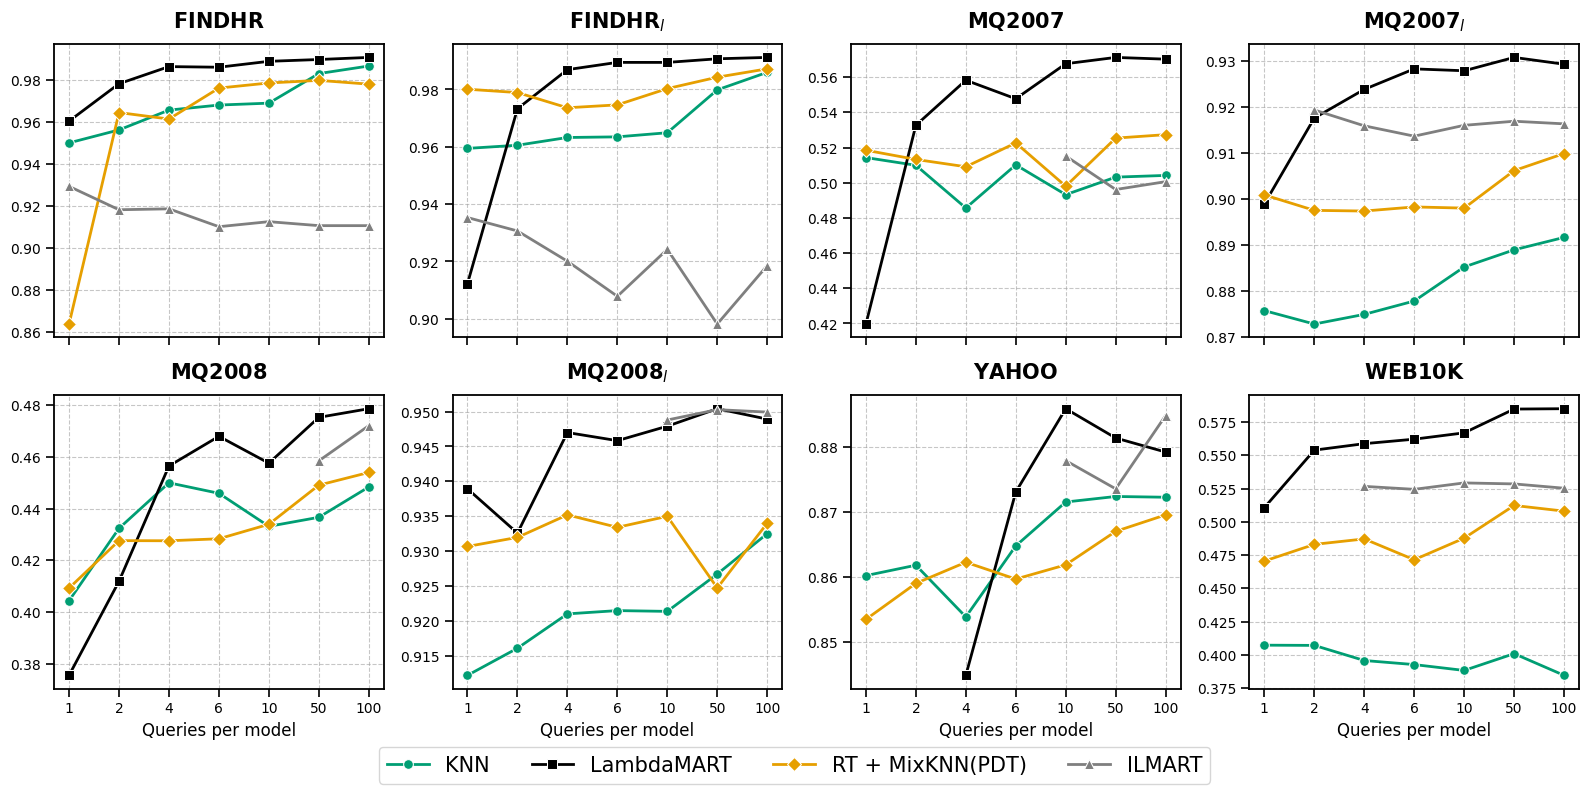

In [24]:
# The x-axis is categorical because qxm values are not evenly spaced.
qxm_order = [1, 2, 4, 6, 10, 50, 100]
qxm_pos = {v: i for i, v in enumerate(qxm_order)}

f, axs = plt.subplots(figsize=(16, 8), nrows=2, ncols=4, sharex=True)
axs = axs.flat

for idx, (ax, (m_result, name)) in enumerate(zip(axs, dataset)):
    tmp_results = m_result[
        m_result.model.isin(all_models_list) & (m_result.fold == "test") & (m_result.k == 10)
    ].copy()
    tmp_results = tmp_results[tmp_results["qxm"].isin(qxm_order)]
    tmp_results["qxm_pos"] = tmp_results["qxm"].map(qxm_pos)

    sns.lineplot(data=tmp_results, x="qxm_pos", y="mean", hue="model", style="model",
                 markers=['o', 's', 'D', '^'], dashes=False, markersize=7, linewidth=2,
                 ax=ax, legend=(idx == 0), palette=palette)
    ax.set_xlabel("Queries per model", fontsize=12)
    ax.set_ylabel("")
    ax.set_title(name, fontsize=15, pad=12)
    ax.set_xticks(range(len(qxm_order)))
    ax.set_xticklabels([str(v) for v in qxm_order])

    ax.tick_params(axis="both", which="major", labelsize=10, length=6, width=1.2)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6, color="#a0a0a0")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.3)
handles, labels = axs[0].get_legend_handles_labels()

for ax in axs:
    if ax.get_legend() is not None: ax.get_legend().remove()

f.legend(
    handles, map(model_rename.get, labels), loc="lower center", ncol=5, fontsize=15, frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("pdfs/qxm_across.pdf", bbox_inches="tight", transparent=True)
plt.show()

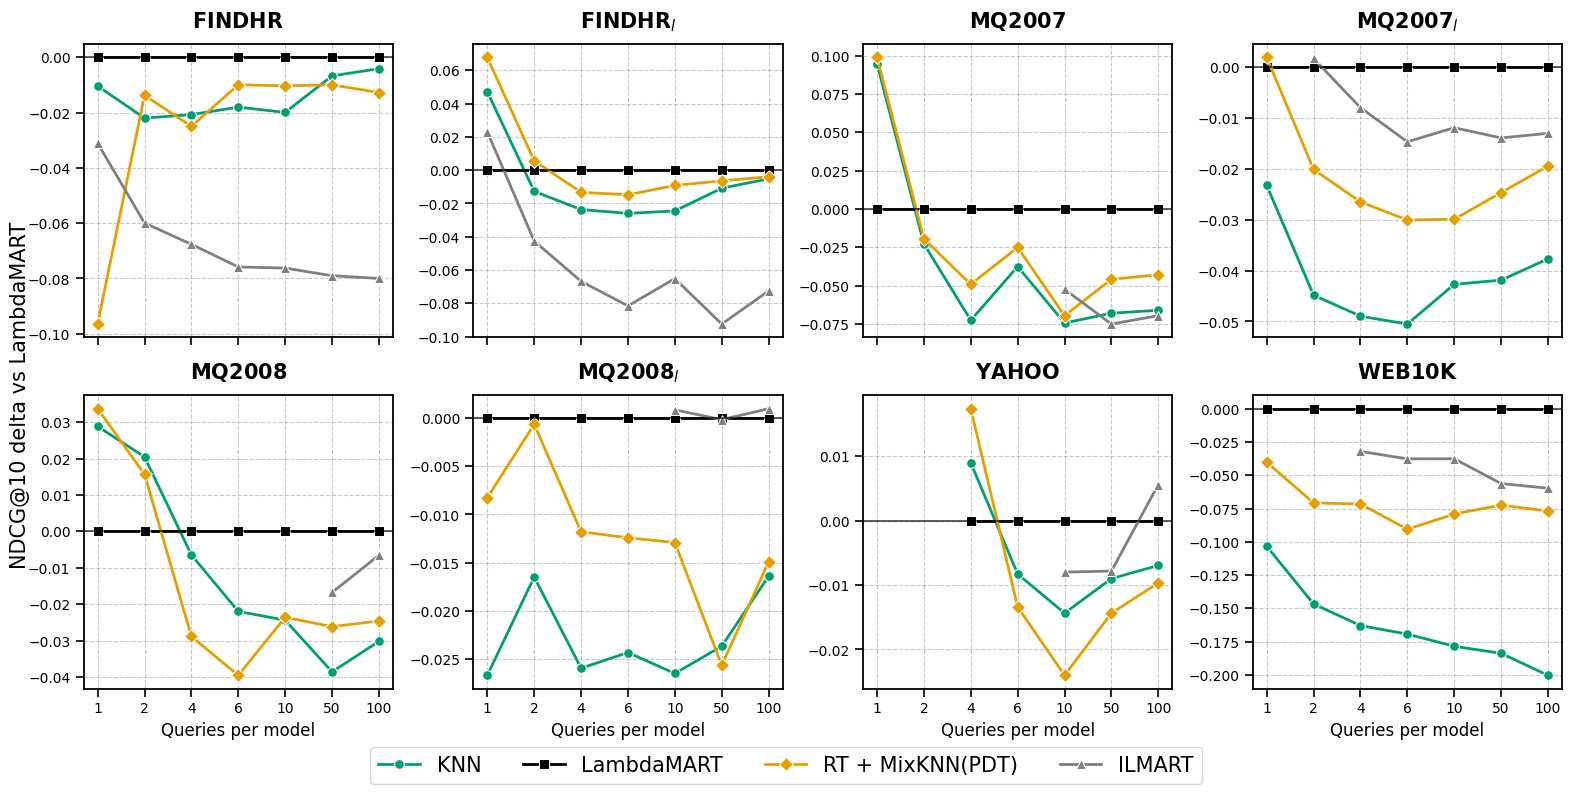

In [26]:
# The x-axis is categorical because qxm values are not evenly spaced.
qxm_order = [1, 2, 4, 6, 10, 50, 100]
qxm_pos = {v: i for i, v in enumerate(qxm_order)}

baseline_model = "LambdaMART"  # Cambia con il nome esatto del tuo baseline

f, axs = plt.subplots(figsize=(16, 8), nrows=2, ncols=4, sharex=True)
axs = axs.flat

for idx, (ax, (m_result, name)) in enumerate(zip(axs, dataset)):
    tmp_results = m_result[
        m_result.model.isin(all_models_list)
        & (m_result.fold == "test")
        & (m_result.k == 10)
    ].copy()

    tmp_results = tmp_results[tmp_results["qxm"].isin(qxm_order)]
    tmp_results["qxm_pos"] = tmp_results["qxm"].map(qxm_pos)

    baseline = tmp_results[tmp_results["model"] == baseline_model][
        ["qxm", "mean"]
    ].rename(columns={"mean": "baseline_mean"})

    tmp_results = tmp_results.merge(baseline, on="qxm", how="left")
    tmp_results["mean_delta"] = tmp_results["mean"] - tmp_results["baseline_mean"]

    sns.lineplot(
        data=tmp_results,
        x="qxm_pos",
        y="mean_delta",
        hue="model",
        style="model",
        markers=["o", "s", "D", "^"],
        dashes=False,
        markersize=7,
        linewidth=2,
        ax=ax,
        legend=(idx == 0),
        palette=palette,
    )

    ax.axhline(0, color="black", linewidth=1.1, linestyle="-", alpha=0.8)

    ax.set_xlabel("Queries per model", fontsize=12)
    ax.set_ylabel("")
    ax.set_title(name, fontsize=15, pad=12)
    ax.set_xticks(range(len(qxm_order)))
    ax.set_xticklabels([str(v) for v in qxm_order])

    ax.tick_params(axis="both", which="major", labelsize=10, length=6, width=1.2)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6, color="#a0a0a0")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.3)

handles, labels = axs[0].get_legend_handles_labels()

for ax in axs:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

f.legend(
    handles,
    [model_rename.get(label, label) for label in labels],
    loc="lower center",
    ncol=5,
    fontsize=15,
    frameon=True,
)

f.supylabel(f"NDCG@10 delta vs {model_rename.get(baseline_model, baseline_model)}", fontsize=15)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("pdfs/qxm_across_delta.pdf", bbox_inches="tight", transparent=True)
plt.show()

## Ablation study

This boxplot compares variants of the RuleTreeRank/KNN pipeline at nDCG@10. The main contrast is between Euclidean grouping and PDT-based grouping, plus the RuleTree-only score variant.

The goal is to isolate whether the gain comes from the mixed ranking strategy, the KNN component, or the query/document similarity metric used to select neighbors.


In [ ]:
# Ablation labels: Euclidean variants are hatched, PDT-based variants are solid.
abl_models_rtr = {
    'KNNwPDT_eucl' : r"KNN($\mathbb{E}$)",
    'KNNwPDT': r"KNN(PDT)",
    'Mix-RuleTreeRank_eucl': r"RT + MixKNN($\mathbb{E}$)",
    'Mix-RuleTreeRank': r"RT + MixKNN(PDT)",
    'RuleTree': "RT"
}
palette_abl = {"KNNwPDT_eucl": "#56B4E9", "KNNwPDT": "#56B4E9", "Mix-RuleTreeRank_eucl": "#E69F00",
           "Mix-RuleTreeRank": "#E69F00", "RuleTree": "#B39DDB",
}
hatches = ["\\\\","", "", "\\\\",""]
f, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), sharex=True)
axs = axs.flat

all_handles, all_labels = None, None

for ax, (model, name) in zip(axs, dataset):
    model.model = model.model.str.replace("Mix-RuleTreeRank_score","RuleTree")
    rtr_abl = model[model.model.isin(abl_models_rtr.keys())]
    sns.boxplot(
        data=rtr_abl, y="mean", hue="model", hue_order=abl_models_rtr,
        linewidth=1.0, orient="v", palette=palette_abl, ax=ax, showfliers=False
    )
    for i, patch in enumerate(ax.patches): patch.set_hatch(hatches[i % len(hatches)])
    ax.grid(None, linestyle="--", linewidth=0.8, alpha=0.6, color="#a0a0a0")
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.2)
    ax.set_title(name, fontsize=15, pad=12)
    ax.set_xlabel("");ax.set_ylabel("");ax.set_xticklabels([])
    all_handles, all_labels = ax.get_legend_handles_labels()
    ax.legend().remove()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.3)

f.legend(
    all_handles, abl_models_rtr.values(), loc="lower center", ncol=5, fontsize=15, frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("pdfs/abl_boxplot.pdf",bbox_inches="tight", transparent=True)
plt.show()